In [1]:
from pathlib import Path

DATA = Path("../data/raw/nasa_ims/IMS")

print("1st:", len(list((DATA/"1st_test").glob("*"))))
print("2nd:", len(list((DATA/"2nd_test").glob("*"))))
print("3rd:", len(list((DATA/"3rd_test"/"3rd_test"/"txt").glob("*"))))
print("4th:", len(list((DATA/"4th_test"/"txt").glob("*"))))

1st: 2156
2nd: 984
3rd: 6324
4th: 6324


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
DATA = Path("../data/raw/nasa_ims/IMS")

sample = sorted(
    (DATA/"1st_test").glob("*")
)[0]

print(sample)

../data/raw/nasa_ims/IMS/1st_test/2003.10.22.12.06.24


In [3]:
df = pd.read_csv(
    sample,
    sep="\t",
    header=None
)

df.head()

,0,1,2,3,4,5,6,7
0,-0.022,-0.039,-0.183,-0.054,-0.105,-0.134,-0.129,-0.142
1,-0.105,-0.017,-0.164,-0.183,-0.049,0.029,-0.115,-0.122
2,-0.183,-0.098,-0.195,-0.125,-0.005,-0.007,-0.171,-0.071
3,-0.178,-0.161,-0.159,-0.178,-0.100,-0.115,-0.112,-0.078
4,-0.208,-0.129,-0.261,-0.098,-0.151,-0.205,-0.063,-0.066


In [4]:
print(df.shape)

(20480, 8)


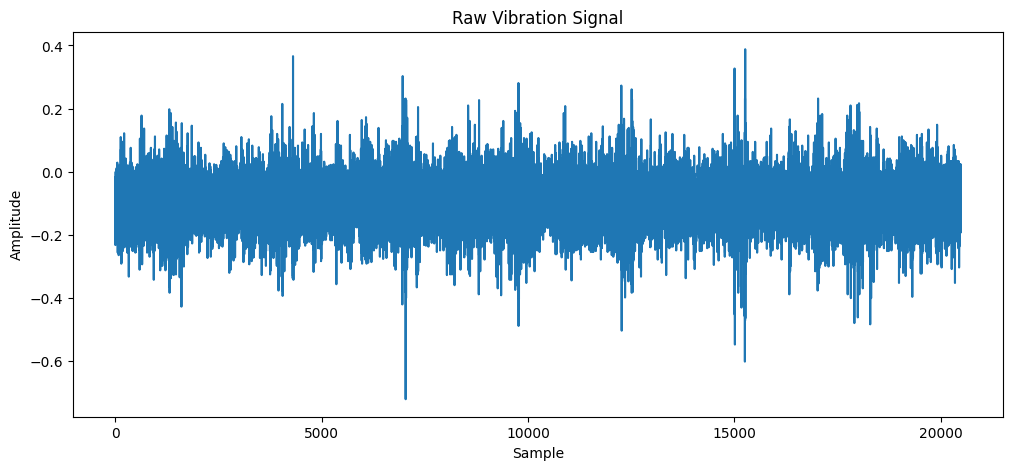

In [5]:
plt.figure(figsize=(12,5))

plt.plot(df.iloc[:,0])

plt.title("Raw Vibration Signal")

plt.xlabel("Sample")

plt.ylabel("Amplitude")

plt.show()

In [6]:
print("Shape:", df.shape)

print("\nStatistics:")
print(df.describe())

Shape: (20480, 8)

Statistics:
                  0            1             2             3             4  \
count  20480.000000  20480.00000  20480.000000  20480.000000  20480.000000   
mean      -0.094593     -0.09388     -0.093817     -0.093752     -0.090812   
std        0.081124      0.07065      0.090650      0.077510      0.091463   
min       -0.720000     -0.56400     -0.674000     -0.530000     -0.496000   
25%       -0.146000     -0.13900     -0.156000     -0.146000     -0.151000   
50%       -0.095000     -0.09300     -0.093000     -0.093000     -0.090000   
75%       -0.042000     -0.04900     -0.032000     -0.042000     -0.029000   
max        0.388000      0.70100      0.359000      0.256000      0.400000   

                  5             6             7  
count  20480.000000  20480.000000  20480.000000  
mean      -0.090881     -0.090969     -0.094235  
std        0.095488      0.060086      0.066382  
min       -0.784000     -0.413000     -0.471000  
25%       -0.154

In [7]:
signal = df.iloc[:,0]

features = {
    "mean": signal.mean(),
    "std": signal.std(),
    "max": signal.max(),
    "min": signal.min(),
    "rms": np.sqrt(np.mean(signal**2)),
    "peak_to_peak": signal.max()-signal.min()
}

features

{'mean': -0.09459287109375,
 'std': 0.0811240654056972,
 'max': 0.388,
 'min': -0.72,
 'rms': 0.12461381908219489,
 'peak_to_peak': 1.108}

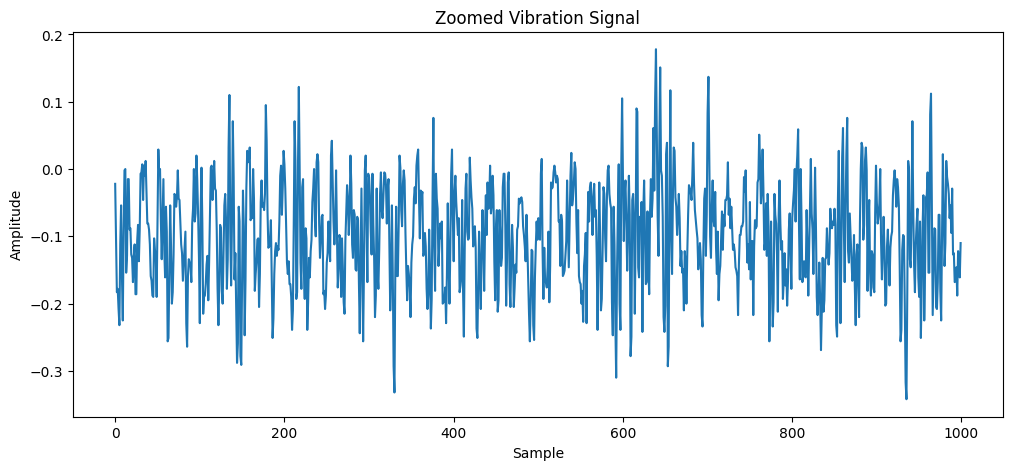

In [9]:
plt.figure(figsize=(12,5))

plt.plot(signal[:1000])

plt.title("Zoomed Vibration Signal")

plt.xlabel("Sample")

plt.ylabel("Amplitude")

plt.show()

In [10]:
import numpy as np
import pandas as pd

signal = df.iloc[:,0]

features = {
    "mean": signal.mean(),
    "std": signal.std(),
    "max": signal.max(),
    "min": signal.min(),
    "rms": np.sqrt(np.mean(signal**2)),
    "peak_to_peak": signal.max()-signal.min(),
    "variance": signal.var(),
    "abs_mean": np.mean(np.abs(signal))
}

feature_df = pd.DataFrame([features])

feature_df

,mean,std,max,min,rms,peak_to_peak,variance,abs_mean
0,-0.094593,0.081124,0.388,-0.72,0.124614,1.108,0.006581,0.104144


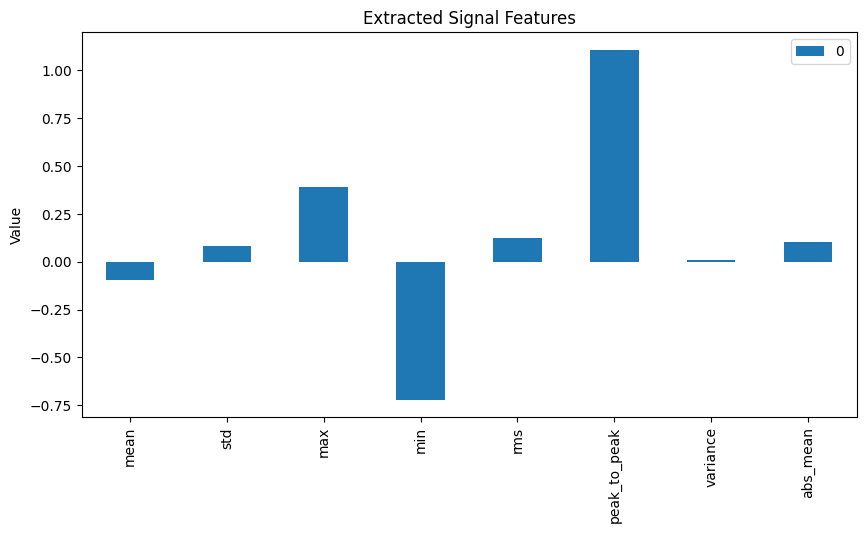

In [11]:
feature_df.T.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Extracted Signal Features")

plt.ylabel("Value")

plt.show()

In [12]:
from pathlib import Path
import pandas as pd
import numpy as np

folder = DATA/"1st_test"

rows = []

files = sorted(folder.glob("*"))[:100]

for f in files:

    df = pd.read_csv(
        f,
        sep="\t",
        header=None
    )

    signal = df.iloc[:,0]

    rows.append({
        "file": f.name,
        "mean": signal.mean(),
        "std": signal.std(),
        "rms": np.sqrt(np.mean(signal**2)),
        "max": signal.max(),
        "min": signal.min(),
        "peak_to_peak": signal.max()-signal.min()
    })

dataset = pd.DataFrame(rows)

dataset.head()

,file,mean,std,rms,max,min,peak_to_peak
0,2003.10.22.12.06.24,-0.094593,0.081124,0.124614,0.388,-0.720,1.108
1,2003.10.22.12.09.13,-0.094903,0.079517,0.123811,0.388,-0.654,1.042
2,2003.10.22.12.14.13,-0.096187,0.080219,0.125246,0.317,-0.623,0.940
3,2003.10.22.12.19.13,-0.095613,0.080827,0.125197,0.457,-0.598,1.055
4,2003.10.22.12.24.13,-0.095133,0.082036,0.125618,0.388,-0.623,1.011


In [13]:
dataset.shape

(100, 7)

In [14]:
dataset.to_csv(
    "../data/processed/features_sample.csv",
    index=False
)